# Module 17 · Biến đổi Laplace: dải hội tụ, đáp ứng quá độ, bài toán giá trị đầu

**Nguồn sách:** Bracewell, chương 14, tr. 380–400

Notebook đi kèm bài giảng cùng số module. Chạy lần lượt từng cell; sau mỗi cell có phần **📤 Đầu ra thật** giải thích con số.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """Phổ biên độ một phía: sóng hình sin biên độ A cho vạch A, thành phần một chiều cho đúng giá trị của nó"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """In một kết quả có tên, bỏ các số 0 thừa ở cuối (trang web đọc các dòng bắt đầu bằng ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Dải hội tụ, định lý, nghịch đảo
🎯 **Phương pháp này trả lời câu hỏi gì?** Tích phân số có khớp $1/(p+1)$, $2/(1-p^2)$ trong dải và phân kỳ ngoài dải, các định lý (dịch, đạo hàm, chập...) có đúng, và nghịch đảo Bromwich có trả lại $te^{-t}$?

In [2]:
from scipy import integrate, signal
from scipy.integrate import solve_ivp
trap = getattr(np, "trapezoid", None) or np.trapz
rg = np.random.default_rng(17)
def lap(fun, p, a=0, b=np.inf, **kw):
    re = integrate.quad(lambda t: (fun(t)*np.exp(-p*t)).real, a, b, limit=400, **kw)[0]
    im = integrate.quad(lambda t: (fun(t)*np.exp(-p*t)).imag, a, b, limit=400, **kw)[0]
    return re + 1j*im
p0 = 0.5
ea = lambda t: np.exp(-t)
a_num = lap(ea, p0).real; assert abs(a_num - 1/(p0 + 1)) < 1e-10
report("lp_a", a_num, ".4f"); report("lp_a_cf", 1/(p0 + 1), ".4f")
two = lambda t: np.exp(-abs(t))
tw = integrate.quad(lambda t: np.exp(-abs(t))*np.exp(-p0*t), -60, 60, points=[0], limit=400)[0]
assert abs(tw - 2/(1 - p0**2)) < 1e-9; report("cv_ab", tw, ".4f")
for T in (10, 20):
    val = integrate.quad(lambda t: np.exp(-t)*np.exp(1.5*t), 0, T)[0]; assert abs(val - (np.exp(0.5*T) - 1)/0.5) < 1e-6*val
report("cv_T10", (np.exp(5) - 1)/0.5, ".1f"); report("cv_T20", (np.exp(10) - 1)/0.5, ".1f")
p5 = 5.0
gsv = integrate.quad(lambda t: np.exp(-t*t - p5*t), -30, 30)[0]; gcf = np.sqrt(np.pi)*np.exp(p5**2/4)
assert abs(gsv - gcf) < 1e-6*gcf; report("gs_p5", gsv, ".2f"); report("gs_p5_cf", gcf, ".2f")
# định lý
F1 = lambda p: 1/(p + 1)
tau = 0.7; a2 = 2.0
th_shift = lap(lambda t: np.exp(-(t - tau)), p0, tau).real; assert abs(th_shift - np.exp(-p0*tau)*F1(p0)) < 1e-9
th_sim = lap(lambda t: np.exp(-a2*t), p0).real; assert abs(th_sim - F1(p0/a2)/a2) < 1e-9
th_mod = lap(lambda t: np.exp(-1.0*t)*np.cos(2*t), p0).real; assert abs(th_mod - (p0 + 1)/((p0 + 1)**2 + 4)) < 1e-9
th_der = 1 - lap(ea, p0).real; assert abs(th_der - p0*F1(p0)) < 1e-12   # f' = −f + δ
th_int = lap(lambda t: 1 - np.exp(-t), p0).real; assert abs(th_int - F1(p0)/p0) < 1e-9
th_conv = lap(lambda t: t*np.exp(-t), p0).real; assert abs(th_conv - F1(p0)**2) < 1e-9
ac = integrate.quad(lambda t: 0.5*np.exp(-abs(t))*np.exp(-p0*t), -60, 60, points=[0], limit=400)[0]; th_ac = F1(p0)*F1(-p0)
assert abs(ac - th_ac) < 1e-8
tf = 0.6
fd = integrate.quad(lambda t: (np.exp(-(t + tf/2))*(t + tf/2 >= 0) - np.exp(-(t - tf/2))*(t - tf/2 >= 0))*np.exp(-p0*t), -tf/2, 60, points=[tf/2], limit=400)[0]
assert abs(fd - 2*np.sinh(p0*tf/2)*F1(p0)) < 1e-9; report("th_fd", max(abs(fd - 2*np.sinh(p0*tf/2)*F1(p0)), 1e-16), ".0e")
report("th_shift", th_shift, ".4f"); report("th_sim", th_sim, ".4f"); report("th_mod", th_mod, ".4f"); report("th_der", th_der, ".4f")
report("th_int", th_int, ".4f"); report("th_conv", th_conv, ".4f"); report("th_ac", th_ac, ".4f")
# Bromwich
c = 0.5; tt = 2.0; Fb = lambda w: 1/((c + 1j*w) + 1)**2
part1 = integrate.quad(lambda w: Fb(w).real, 0, np.inf, weight="cos", wvar=tt)[0]
part2 = integrate.quad(lambda w: Fb(w).imag, 0, np.inf, weight="sin", wvar=tt)[0]
inv = np.exp(c*tt)/np.pi*(part1 - part2)
assert abs(inv - tt*np.exp(-tt)) < 1e-7; report("inv_num", inv, ".4f"); report("inv_cf", tt*np.exp(-tt), ".4f")

▸ lp_a = 0.6667
▸ lp_a_cf = 0.6667
▸ cv_ab = 2.6667
▸ cv_T10 = 294.8
▸ cv_T20 = 44050.9
▸ gs_p5 = 918.15
▸ gs_p5_cf = 918.15
▸ th_fd = 1e-16
▸ th_shift = 0.4698
▸ th_sim = 0.4
▸ th_mod = 0.24
▸ th_der = 0.3333
▸ th_int = 1.3333
▸ th_conv = 0.4444
▸ th_ac = 1.3333
▸ inv_num = 0.2707
▸ inv_cf = 0.2707


#### 📤 Đầu ra thật
Trong dải: 0.6667, 2.6667; ngoài dải: 294.8 và 44050.9; Gauss 918.15; định lý: dịch 0.4698, đồng dạng 0.4, điều biến 0.24, đạo hàm 0.3333, tích phân 1.3333, chập 0.4444, tự tương quan 1.3333; Bromwich 0.2707 so với 0.2707.

## 2. Bộ cặp Laplace, Fourier, phân thức đơn giản
🎯 **Phương pháp này trả lời câu hỏi gì?** Mười một cặp của bảng 14.2 có đúng cho $p$ thực và phức, quan hệ với Fourier khi dải chứa trục ảo, và phân thức đơn giản ba cực có đúng?

In [3]:
p1 = 1.2; a_ = 0.7
report("pr_H", lap(lambda t: 1.0, p1).real, ".4f"); assert abs(lap(lambda t: 1.0, p1).real - 1/p1) < 1e-10
pairs = [
    ("H", lambda t: 1.0, lambda p: 1/p),
    ("tH", lambda t: t, lambda p: 1/p**2),
    ("exp", lambda t: np.exp(-a_*t), lambda p: 1/(p + a_)),
    ("texp", lambda t: t*np.exp(-a_*t), lambda p: 1/(p + a_)**2),
    ("cos", lambda t: np.cos(2*t), lambda p: p/(p**2 + 4)),
    ("sin", lambda t: np.sin(2*t), lambda p: 2/(p**2 + 4)),
    ("dcos", lambda t: np.exp(-0.5*t)*np.cos(2*t), lambda p: (p + 0.5)/((p + 0.5)**2 + 4)),
    ("dsin", lambda t: np.exp(-0.5*t)*np.sin(2*t), lambda p: 2/((p + 0.5)**2 + 4)),
    ("1me", lambda t: 1 - np.exp(-a_*t), lambda p: a_/(p*(p + a_))),
]
dev = 0
for nm, fn, Fp in pairs:
    for pp in (1.2, 1.1 + 0.9j):
        v = lap(fn, pp); dev = max(dev, abs(v - Fp(pp)))
assert dev < 1e-7; report("pairs_dev", max(dev, 1e-16), ".0e")
vals = {nm: lap(fn, 1.2).real for nm, fn, Fp in pairs}
report("pr_tH", vals["tH"], ".4f"); report("pr_e", vals["exp"], ".4f"); report("pr_te", vals["texp"], ".4f")
report("pr_cos", vals["cos"], ".4f"); report("pr_sin", vals["sin"], ".4f"); report("pr_dc", vals["dcos"], ".4f"); report("pr_ds", vals["dsin"], ".4f"); report("pr_1me", vals["1me"], ".4f")
pw = 0.8
rect = integrate.quad(lambda t: np.exp(-pw*t), -0.5, 0.5)[0]; assert abs(rect - 2*np.sinh(pw/2)/pw) < 1e-12
tri = integrate.quad(lambda t: (1 - abs(t))*np.exp(-pw*t), -1, 1, points=[0])[0]; assert abs(tri - (2*np.sinh(pw/2)/pw)**2) < 1e-10
report("pr_rect", rect, ".4f"); report("pr_tri", tri, ".4f")
two6 = integrate.quad(lambda t: np.exp(-abs(t))*np.exp(-0.6*t), -80, 80, points=[0], limit=400)[0]; assert abs(two6 - 2/(1 - 0.36)) < 1e-9
report("pr_two", two6, ".4f")
# hàm phía trái: −e^{−at}H(−t)
al = 0.5; pl = -2.0
left = integrate.quad(lambda t: -np.exp(-al*t)*np.exp(-pl*t), -60, 0)[0]; assert abs(left - 1/(pl + al)) < 1e-9
report("pr_left", left, ".4f"); report("pr_left_cf", 1/(pl + al), ".4f")
# Fourier
f0 = 0.3; pF = 2j*np.pi*f0
ftn = lap(lambda t: np.exp(-t), pF)
assert abs(ftn - 1/(1 + pF)) < 1e-10; report("fl_mag", abs(ftn), ".4f")
ft2 = integrate.quad(lambda t: np.exp(-abs(t))*np.cos(2*np.pi*f0*t), -60, 60, points=[0], limit=400)[0]
assert abs(ft2 - 2/(1 + 4*np.pi**2*f0**2)) < 1e-8; report("fl_2", ft2, ".4f")
# phân thức đơn giản
num = np.array([1.0]); den = np.poly([2, 1, -1])
r, pole, k = signal.residue(num, den)
res = {round(float(pl_.real)): rr.real for rr, pl_ in zip(r, pole)}
Fpol = lambda p: 1/((p - 2)*(p - 1)*(p + 1))
A_ = 1/((2 - 1)*(2 + 1)); B_ = 1/((1 - 2)*(1 + 1)); C_ = 1/((-1 - 2)*(-1 - 1))
assert abs(res[2] - A_) < 1e-12 and abs(res[1] - B_) < 1e-12 and abs(res[-1] - C_) < 1e-12
report("pf_a", A_, ".4f"); report("pf_b", B_, ".4f"); report("pf_c", C_, ".4f")

▸ pr_H = 0.8333
▸ pairs_dev = 3e-11
▸ pr_tH = 0.6944
▸ pr_e = 0.5263
▸ pr_te = 0.277
▸ pr_cos = 0.2206
▸ pr_sin = 0.3676
▸ pr_dc = 0.2467
▸ pr_ds = 0.2903
▸ pr_1me = 0.307
▸ pr_rect = 1.0269
▸ pr_tri = 1.0545
▸ pr_two = 3.125
▸ pr_left = -0.6667
▸ pr_left_cf = -0.6667
▸ fl_mag = 0.4686
▸ fl_2 = 0.4393
▸ pf_a = 0.3333
▸ pf_b = -0.5
▸ pf_c = 0.1667


#### 📤 Đầu ra thật
Chín cặp lệch 3e-11; $\cos$ 0.2206, $\sin$ 0.3676, $\Pi$ 1.0269, $\Lambda$ 1.0545, hai phía 3.125, phía trái -0.6667; Fourier 0.4686, 0.4393; thặng dư 0.3333, -0.5, 0.1667.

## 3. Đáp ứng quá độ, mạch LR, nghiệm bội
🎯 **Phương pháp này trả lời câu hỏi gì?** Đáp ứng của mạch RL với $e^{-|t|}$ tính bằng tích phân chồng chất, giải ODE và phân thức đơn giản theo dải có khớp nhau, nghiệm bội có sinh $te^{\lambda t}$, và các đáp số bài 9 và 11 có đúng?

In [4]:
# RL, R = L = 1, v = e^{-|t|}
def i_cf(t): return (t + 0.5)*np.exp(-t) if t > 0 else 0.5*np.exp(t)
def i_conv(t): return integrate.quad(lambda u: np.exp(-u)*np.exp(-abs(t - u)), 0, 80, points=[t] if t > 0 else None, limit=400)[0]
for t in (-2.0, -1.0, 0.0, 0.5, 1.0, 3.0): assert abs(i_conv(t) - i_cf(t)) < 1e-9
sol = solve_ivp(lambda t, y: [-y[0] + np.exp(-abs(t))], [-30, 3], [0.5*np.exp(-30)], t_eval=[-1.0, 0.0, 1.0], rtol=1e-11, atol=1e-14)
dev_ode = max(abs(sol.y[0][k] - i_cf(t)) for k, t in enumerate([-1.0, 0.0, 1.0])); assert dev_ode < 1e-8
report("lr_0", i_cf(0.0), ".1f"); report("lr_1", i_cf(1.0), ".4f"); report("lr_m1", i_cf(-1.0), ".4f"); report("lr_dev", max(dev_ode, 1e-16), ".0e")
# phân thức đơn giản của 2/((p+1)²(1−p))
Bc = 2/(1 - (-1)); Cc = 2/((-1 - 1)**2*1) if False else 2/(2**2)
Ac = 2/(1 - (-1))**2
Ftot = lambda p: 2/((p + 1)**2*(1 - p))
for pp in (0.3, -0.4 + 0.5j): assert abs(Ftot(pp) - (Ac/(pp + 1) + Bc/(pp + 1)**2 + Cc/(1 - pp))) < 1e-12
report("lp_A", Ac, ".1f"); report("lp_B", Bc, ".1f"); report("lp_C", Cc, ".1f")
ts = np.linspace(-4, 6, 501); igrid = np.array([i_cf(t) for t in ts])
# nghiệm bội
rt = np.roots([1, 3, 2]); assert np.allclose(sorted(rt.real), [-2, -1])
report("ch_r1", max(rt.real), ".0f"); report("ch_r2", min(rt.real), ".0f")
lam_, tv, dl = -1.0, 2.0, 1e-6
lim = (np.exp((lam_ + dl)*tv) - np.exp(lam_*tv))/dl; assert abs(lim - tv*np.exp(lam_*tv)) < 1e-5
report("rr_lim", lim, ".4f"); report("rr_cf", tv*np.exp(lam_*tv), ".4f"); report("rr_dev", abs(lim - tv*np.exp(lam_*tv)), ".0e")
# Bài 9
Rr, Ll, om = 2.0, 1.0, 3.0; t9 = 1.5
cf9 = (Ll*om*np.exp(-Rr*t9/Ll) - Ll*om*np.cos(om*t9) + Rr*np.sin(om*t9))/(Rr**2 + Ll**2*om**2)
num9 = integrate.quad(lambda u: (1/Ll)*np.exp(-Rr*u/Ll)*np.sin(om*(t9 - u)), 0, t9)[0]
ode9 = solve_ivp(lambda t, y: [(np.sin(om*t) - Rr*y[0])/Ll], [0, t9], [0.0], rtol=1e-11, atol=1e-13).y[0][-1]
assert abs(cf9 - num9) < 1e-9 and abs(cf9 - ode9) < 1e-8
report("p9_cf", cf9, ".4f"); report("p9_num", num9, ".4f"); report("p9_ode", ode9, ".4f")
a11 = 0.5; t11 = 1.0
cf11 = (np.exp(-a11*t11) - np.exp(-Rr*t11/Ll))/(Rr - a11*Ll)
num11 = integrate.quad(lambda u: (1/Ll)*np.exp(-Rr*u/Ll)*np.exp(-a11*(t11 - u)), 0, t11)[0]
assert abs(cf11 - num11) < 1e-10; report("p11_cf", cf11, ".4f"); report("p11_num", num11, ".4f")

▸ lr_0 = 0.5
▸ lr_1 = 0.5518
▸ lr_m1 = 0.1839
▸ lr_dev = 4e-11
▸ lp_A = 0.5
▸ lp_B = 1
▸ lp_C = 0.5
▸ ch_r1 = -1
▸ ch_r2 = -2
▸ rr_lim = 0.2707
▸ rr_cf = 0.2707
▸ rr_dev = 3e-07
▸ p9_cf = -0.0903
▸ p9_num = -0.0903
▸ p9_ode = -0.0903
▸ p11_cf = 0.3141
▸ p11_num = 0.3141


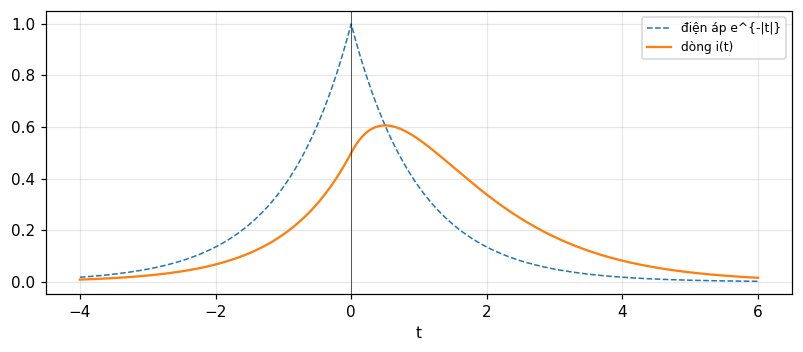

In [5]:
fig, ax = plt.subplots(figsize=(7.4, 3.3))
vv = np.exp(-np.abs(ts)); ax.plot(ts, vv, "--", lw=1, label=("điện áp e^{-|t|}")); ax.plot(ts, igrid, label=("dòng i(t)"))
ax.axvline(0, color="k", lw=0.4); ax.set_xlabel("t"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Mạch RL: $i(0)$ = 0.5, $i(1)$ = 0.5518, $i(-1)$ = 0.1839 (lệch 4e-11); phân thức 0.5, 1, 0.5; nghiệm -1, -2; nghiệm bội 0.2707 so với 0.2707; bài 9: -0.0903, -0.0903, -0.0903; bài 11: 0.3141.

## 4. Bài toán giá trị đầu và đóng cắt
🎯 **Phương pháp này trả lời câu hỏi gì?** Phương pháp xung cho $y=1$ khớp giải ODE, ba đáp số bài 19 có đúng, định lý đạo hàm một phía có đúng, và mạch RC đóng cắt có ra $\tfrac12(\cos t+\sin t-e^{-t})$?

In [6]:
# y'' + 3y' + 2y = 2, y(0)=1, y'(0)=0
for pp in (0.7, 1.9, 0.4 + 0.6j):
    Ynum = pp + 3 + 2/pp; Yden = pp**2 + 3*pp + 2
    assert abs(Ynum/Yden - 1/pp) < 1e-12
report("iv_dev", max(abs((0.7 + 3 + 2/0.7)/(0.7**2 + 3*0.7 + 2) - 1/0.7), 1e-16), ".0e") if False else report("iv_dev", max(abs((0.7 + 3 + 2/0.7) - (0.7**2 + 3*0.7 + 2)/0.7), 1e-16), ".0e")
so = solve_ivp(lambda t, y: [y[1], 2 - 3*y[1] - 2*y[0]], [0, 1.5], [1.0, 0.0], t_eval=[0.5, 1.5], rtol=1e-11, atol=1e-13)
assert np.allclose(so.y[0], [1, 1], atol=1e-9)
report("iv_y", so.y[0][0], ".4f"); report("iv_y2", so.y[0][1], ".4f")
# định lý đạo hàm một phía
pd_ = 0.9; y0, dy0 = 1.0, -2.0
d1 = integrate.quad(lambda t: -2*np.exp(-2*t)*np.exp(-pd_*t), 0, np.inf)[0]; d2 = integrate.quad(lambda t: 4*np.exp(-2*t)*np.exp(-pd_*t), 0, np.inf)[0]
Yb = 1/(pd_ + 2)
assert abs(d1 - (pd_*Yb - y0)) < 1e-10 and abs(d2 - (pd_**2*Yb - pd_*y0 - dy0)) < 1e-10
report("dt_1", d1, ".4f"); report("dt_2", d2, ".4f")
# Bài 19
y0, dy0 = 0.5, -1.0; t8 = 0.8
ca = 1 + (y0 - 1)*np.exp(-t8)
cb = 1 + (3*y0 + dy0 - 3)*np.exp(-2*t8) + (2 - dy0 - 2*y0)*np.exp(-3*t8)
cc = (1 + y0 + dy0)*t8*np.exp(-t8) + (1 + y0)*np.exp(-t8) - np.cos(t8)
oa = solve_ivp(lambda t, y: [1 - y[0]], [0, t8], [y0], rtol=1e-12, atol=1e-14).y[0][-1]
ob = solve_ivp(lambda t, y: [y[1], 6 - 5*y[1] - 6*y[0]], [0, t8], [y0, dy0], rtol=1e-12, atol=1e-14).y[0][-1]
oc = solve_ivp(lambda t, y: [y[1], 2*np.sin(t) - 2*y[1] - y[0]], [0, t8], [y0, dy0], rtol=1e-12, atol=1e-14).y[0][-1]
assert abs(ca - oa) < 1e-9 and abs(cb - ob) < 1e-9 and abs(cc - oc) < 1e-9
report("i19_a", max(abs(ca - oa), 1e-16), ".0e"); report("i19_b", max(abs(cb - ob), 1e-16), ".0e"); report("i19_c", max(abs(cc - oc), 1e-16), ".0e")
# (b) bằng thặng dư
num_b = np.array([y0, dy0 + 5*y0 + 6.0*0])
# ȳ(p) = [y0 p + dy0 + 5 y0 + 6/p]/(p²+5p+6) = [y0 p² + (dy0 + 5 y0) p + 6]/(p (p²+5p+6))
numb = np.array([y0, dy0 + 5*y0, 6.0]); denb = np.polymul([1, 0], [1, 5, 6])
rb, pb, kb = signal.residue(numb, denb)
yres = np.sum(rb*np.exp(pb*t8)).real; assert abs(yres - cb) < 1e-10
report("i19_b_val", yres, ".4f")
# mạch RC đóng cắt
vc = lambda t: 0.5*(np.cos(t) + np.sin(t) - np.exp(-t))
osw = solve_ivp(lambda t, y: [np.cos(t) - y[0]], [0, 2.0], [0.0], rtol=1e-12, atol=1e-14).y[0][-1]
assert abs(osw - vc(2.0)) < 1e-9
report("sw_val", vc(2.0), ".4f"); report("sw_ss", 0.5*(np.cos(2.0) + np.sin(2.0)), ".4f"); report("sw_tr", -0.5*np.exp(-2.0), ".4f"); report("sw_dev", max(abs(osw - vc(2.0)), 1e-16), ".0e")

▸ iv_dev = 1e-16
▸ iv_y = 1
▸ iv_y2 = 1
▸ dt_1 = -0.6897
▸ dt_2 = 1.3793
▸ i19_a = 8e-14
▸ i19_b = 4e-14
▸ i19_c = 3e-14
▸ i19_b_val = 0.6767
▸ sw_val = 0.1789
▸ sw_ss = 0.2466
▸ sw_tr = -0.0677
▸ sw_dev = 8e-14


#### 📤 Đầu ra thật
$y(0.5)$ = 1, $y(1.5)$ = 1; đạo hàm một phía -0.6897, 1.3793; bài 19: 8e-14, 4e-14, 3e-14, (b) 0.6767; mạch đóng cắt 0.1789 = 0.2466 + -0.0677.

## 5. Bốn hàm một $F(p)$, hàm bậc thang, RLC
🎯 **Phương pháp này trả lời câu hỏi gì?** Bốn hàm ứng với bốn dải có cùng $F(p)$, dùng sai dải phân kỳ, hàm bậc thang có $1/[p(1-e^{-pT})]$, dạng $0^-$ có đúng, và RLC có đáp ứng gù?

In [7]:
e2 = lambda t: np.exp(2*t); e1 = lambda t: np.exp(t); em = lambda t: np.exp(-t)
Hs = lambda t: 1.0*(t > 0)
f_i = lambda t: (e2(t)/3 - e1(t)/2 + em(t)/6)*(t > 0)
f_ii = lambda t: -e2(t)/3*(t < 0) - (e1(t)/2 - em(t)/6)*(t > 0)
f_iii = lambda t: -e2(t)/3*(t < 0) + e1(t)/2*(t < 0) + em(t)/6*(t > 0)
f_iv = lambda t: -(e2(t)/3 - e1(t)/2 + em(t)/6)*(t < 0)
def lap2(f, p):
    a = integrate.quad(lambda t: f(t)*np.exp(-p*t), -60, 0, limit=400)[0]
    b = integrate.quad(lambda t: f(t)*np.exp(-p*t), 0, 60, limit=400)[0]
    return a + b
tests = ((f_i, 3.0), (f_ii, 1.5), (f_iii, 0.0), (f_iv, -2.0))
for fn, pp in tests: assert abs(lap2(fn, pp) - Fpol(pp)) < 1e-8
report("fs_1", Fpol(3.0), ".4f"); report("fs_2", Fpol(1.5), ".4f"); report("fs_3", Fpol(0.0), ".4f"); report("fs_4", Fpol(-2.0), ".4f")
# dùng sai dải
v5 = integrate.quad(lambda t: f_i(t), 0, 5)[0]; v10 = integrate.quad(lambda t: f_i(t), 0, 10)[0]
assert v10 > 100*v5 > 100
report("dv_5", v5, ".1f"); report("dv_10", v10, ".1f")
# bậc thang
ps_, Ts = 1.2, 0.7
stair_cf = 1/(ps_*(1 - np.exp(-ps_*Ts)))
stair_sum = np.sum(np.exp(-ps_*np.arange(300)*Ts))/ps_
tgr = np.linspace(0, 40, 400001)
stairf = np.floor(tgr/Ts) + 1
stair_num = trap(stairf*np.exp(-ps_*tgr), tgr)
assert abs(stair_cf - stair_sum) < 1e-12 and abs(stair_cf - stair_num) < 2e-3
report("stair", stair_cf, ".4f"); report("stair_dev", max(abs(stair_cf - stair_num), 1e-16), ".0e")
# dạng 0^-
pd_ = 0.9
pre1 = integrate.quad(lambda t: -2*np.exp(-2*t)*np.exp(-pd_*t), 0, np.inf)[0]; Fm = 1/(pd_ + 2)
assert abs(pre1 - (pd_*Fm - 1)) < 1e-10; report("pre_1", pre1, ".4f")
pre2 = 1 + integrate.quad(lambda t: -2*np.exp(-2*t)*np.exp(-pd_*t), 0, np.inf)[0]
assert abs(pre2 - pd_*Fm) < 1e-10; report("pre_2", pre2, ".4f")
# mạch RC với cos ωt H(t) (Bài 10)
Rc, Cc_, w_, t10 = 2.0, 0.5, 3.0, 1.2; tauc = Rc*Cc_
Ih = lambda t: (1/Rc)*(0 if t < 0 else 1)  # không dùng
def i_rc(t):
    # đáp ứng dòng = Cp/(1+RCp) → δ/R − e^{-t/RC}/(R²C)
    imp = (1/Rc)*np.cos(w_*t)
    conv = -integrate.quad(lambda u: np.exp(-u/tauc)/(Rc**2*Cc_)*np.cos(w_*(t - u)), 0, t)[0]
    return imp + conv
def ode_rc(t):
    # R C v' + v = cos, i = C v'
    sol_ = solve_ivp(lambda tt, y: [(np.cos(w_*tt) - y[0])/tauc], [0, t], [0.0], rtol=1e-12, atol=1e-14).y[0][-1]
    return Cc_*(np.cos(w_*t) - sol_)/tauc
Ip = i_rc(t10); Io = ode_rc(t10); assert abs(Ip - Io) < 1e-9
# tách ổn định và quá độ
Y_ = 1j*w_*Cc_/(1 + 1j*w_*tauc); iss = (Y_*np.exp(1j*w_*t10)).real
itr = Ip - iss
Ay = w_*Cc_/np.sqrt(1 + (w_*tauc)**2)
assert abs(itr - (Io - iss)) < 1e-9
report("p10_num", Ip, ".4f"); report("p10_ode", Io, ".4f"); report("p10_ss", iss, ".4f"); report("p10_tr", itr, ".4f")
# RLC: L=1, R=3, 1/C=2
q_imp = lambda t: np.exp(-t) - np.exp(-2*t); tm = np.log(2)
assert abs(q_imp(tm) - 0.25) < 1e-12
step = lambda t: 0.5 - np.exp(-t) + 0.5*np.exp(-2*t)
st_int = integrate.quad(q_imp, 0, 1.0)[0]; assert abs(st_int - step(1.0)) < 1e-12
Ostep = solve_ivp(lambda t, y: [y[1], 1 - 3*y[1] - 2*y[0]], [0, 1.0], [0, 0], rtol=1e-12, atol=1e-14).y[0][-1]; assert abs(Ostep - step(1.0)) < 1e-9
report("rl_tm", tm, ".4f"); report("rl_max", q_imp(tm), ".2f"); report("rl_step", step(1.0), ".4f")

▸ fs_1 = 0.125
▸ fs_2 = -1.6
▸ fs_3 = 0.5
▸ fs_4 = -0.0833
▸ dv_5 = 3597.4
▸ dv_10 = 80849853.2
▸ stair = 1.4664
▸ stair_dev = 4e-05
▸ pre_1 = -0.6897
▸ pre_2 = 0.3103
▸ p10_num = -0.3221
▸ p10_ode = -0.3221
▸ p10_ss = -0.3372
▸ p10_tr = 0.0151
▸ rl_tm = 0.6931
▸ rl_max = 0.25
▸ rl_step = 0.1998


#### 📤 Đầu ra thật
Bốn hàm: 0.125, -1.6, 0.5, -0.0833; dùng sai dải: 3597.4, 80849853.2; bậc thang 1.4664; dạng $0^-$: -0.6897, 0.3103; RC: -0.3221, -0.3221; RLC: 0.6931, 0.25, 0.1998.